# 2. Preprocessing & Dataset Pipeline

Create Train/Test Split and complete tf.data pipeline for Siamese Network training.

**Features:**
- Image Resize zu 100x100
- Normalization [0, 1]
- On-The-Fly Augmentation Integration
- Batching & Prefetching für Performance
- Train/Test Split (70/30)


## 2.1 Import & Setup

In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Project
sys.path.insert(0, str(Path.cwd().parent))
import config
from src import data
from src import utils

print("✓ Imports successful")

✓ Imports successful


## 2.2 Load Images

In [2]:
print("Loading image paths...\n")

try:
    anchor_paths = data.load_image_paths(str(config.ANCHOR_PATH))
    positive_paths = data.load_image_paths(str(config.POSITIVE_PATH))
    negative_paths = data.load_image_paths(str(config.NEGATIVE_PATH))

    print(f"✓ {len(anchor_paths)} Anchor images")
    print(f"✓ {len(positive_paths)} Positive images")
    print(f"✓ {len(negative_paths)} Negative images")
    print(f"✓ Total: {len(anchor_paths) + len(positive_paths) + len(negative_paths)} images")

except Exception as e:
    print(f"✗ Error loading paths: {e}")
    anchor_paths = positive_paths = negative_paths = []

Loading image paths...

✓ 400 Anchor images
✓ 400 Positive images
✓ 400 Negative images
✓ Total: 1200 images


## 2.3 Preprocessing Function Test

Testing Preprocessing Pipeline...

Original Image:
  Shape: (750, 750, 3)
  Type: <dtype: 'uint8'>
  Range: [4, 255]

Processed Image:
  Shape: (100, 100, 3)
  Type: <dtype: 'float32'>
  Range: [0.0206, 1.0000]
  Expected Size: 100x100x3


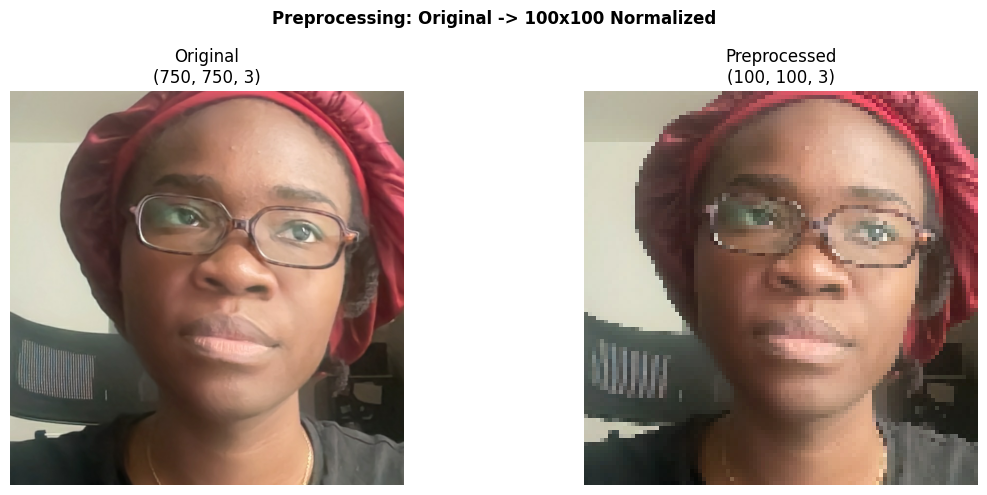


✓ Preprocessing is working correctly


In [3]:
if anchor_paths:
    print("Testing Preprocessing Pipeline...\n")

    # Load image
    img = data.load_image(anchor_paths[0])
    print(f"Original Image:")
    print(f"  Shape: {img.shape}")
    print(f"  Type: {img.dtype}")
    print(f"  Range: [{img.numpy().min()}, {img.numpy().max()}]")

    # Preprocess
    processed = data.preprocess_image(img)
    print(f"\nProcessed Image:")
    print(f"  Shape: {processed.shape}")
    print(f"  Type: {processed.dtype}")
    print(f"  Range: [{processed.numpy().min():.4f}, {processed.numpy().max():.4f}]")
    print(f"  Expected Size: {config.IMG_SIZE}x{config.IMG_SIZE}x{config.IMG_CHANNELS}")

    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img.numpy().astype(np.uint8))
    axes[0].set_title(f"Original\n{img.shape}")
    axes[0].axis('off')

    axes[1].imshow(processed.numpy())
    axes[1].set_title(f"Preprocessed\n{processed.shape}")
    axes[1].axis('off')

    plt.suptitle('Preprocessing: Original -> 100x100 Normalized', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\n✓ Preprocessing is working correctly")
else:
    print(" No images found")

## 2.4 Create Triplet Dataset

In [4]:
if anchor_paths and positive_paths and negative_paths:
    print("\nCreating Triplet Dataset with On-The-Fly Augmentation...\n")

    # Create Dataset
    dataset = data.create_triplet_dataset(
        anchor_paths,
        positive_paths,
        negative_paths,
        apply_augmentation=True
    )

    print(f"✓ Dataset created")
    print(f"  Element Spec: {dataset.element_spec}")

    # Show Sample
    for anchor, verification, label in dataset.take(1):
        print(f"\nExample Sample:")
        print(f"  Anchor: {anchor.shape}")
        print(f"  Verification: {verification.shape}")
        print(f"  Label: {label.numpy()}")
else:
    dataset = None
    print(" Not all directories contain images")


Creating Triplet Dataset with On-The-Fly Augmentation...


 Dataset Balancing:
  Anchor/Positive Pairs: 400
  Negative Samples:     400
  Total Pairs per Epoch: 800
✓ Dataset created
  Element Spec: (TensorSpec(shape=(100, 100, 3), dtype=tf.float32, name=None), TensorSpec(shape=(100, 100, 3), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.float32, name=None))

Example Sample:
  Anchor: (100, 100, 3)
  Verification: (100, 100, 3)
  Label: 1.0


In [5]:
train_data, test_data = data.load_all_datasets(
    str(config.ANCHOR_PATH),
    str(config.POSITIVE_PATH),
    str(config.NEGATIVE_PATH),
    apply_augmentation=False
)

for anchor, img, label in train_data.take(1):
    print(anchor.shape, img.shape, label.shape)
    print(label.numpy())
    print("Train batches:", len(train_data))
    print("Test batches:", len(test_data))

Loading Anchor Images from: /Users/angelica.allieu/PycharmProjects/Doyourecognizeme/data/anchor
  ✓ 400 Anchor Images loaded
Loading Positive Images from: /Users/angelica.allieu/PycharmProjects/Doyourecognizeme/data/positive
  ✓ 400 Positive Images loaded
Loading Negative Images from: /Users/angelica.allieu/PycharmProjects/Doyourecognizeme/data/negative
  ✓ 400 Negative Images loaded

 Image-Level Split):
  Training: 280 Anchors + 280 Positives
  Test:     120 Anchors + 120 Positives
  Training Negatives: 280
  Test Negatives:     120

Create Train dataset...

 Dataset Balancing:
  Anchor/Positive Pairs: 280
  Negative Samples:     280
  Total Pairs per Epoch: 560

Create Test dataset...

 Dataset Balancing:
  Anchor/Positive Pairs: 120
  Negative Samples:     120
  Total Pairs per Epoch: 240

Prepare Train Pipeline...
Prepare Test Pipeline...
  ✓ Train Dataset: 35 Batches
  ✓ Test Dataset: 15 Batches
(16, 100, 100, 3) (16, 100, 100, 3) (16,)
[0. 1. 1. 0. 1. 0. 0. 1. 1. 0. 0. 1. 1. 1. 

## 2.5 Train/Test Split & Pipeline Preparation

In [6]:
if dataset is not None:
    print("\nPreparing Train/Test Pipeline...\n")

    # Create Train/Test Split
    train_data, test_data = data.prepare_dataset_pipeline(
        dataset,
        shuffle_buffer=config.DatasetConfig.SHUFFLE_BUFFER,
        batch_size=config.BATCH_SIZE,
        prefetch_buffer=config.DatasetConfig.PREFETCH_BUFFER,
        train_split=config.TRAIN_SIZE
    )

    print(f"✓ Pipeline created")
    print(f"\nTrain Dataset:")
    utils.print_dataset_info(train_data, "Train Dataset")

    print(f"\nTest Dataset:")
    utils.print_dataset_info(test_data, "Test Dataset")

    # Calculate sizes
    train_steps = len(list(train_data))
    test_steps = len(list(test_data))

    print(f"\nDataset Metrics:")
    print(f"  Train Steps: {train_steps} (Batch Size={config.BATCH_SIZE})")
    print(f"  Test Steps: {test_steps} (Batch Size={config.BATCH_SIZE})")
    print(f"  Total Samples (approx): {(train_steps + test_steps) * config.BATCH_SIZE}")
    print(f"  Train/Test Split: {config.TRAIN_SIZE:.0%} / {config.TEST_SIZE:.0%}")
else:
    train_data = test_data = None


Preparing Train/Test Pipeline...

✓ Pipeline created

Train Dataset:

Train Dataset Info:
  Element Spec: (TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))
  Anchor Shape: (16, 100, 100, 3)
  Verification Shape: (16, 100, 100, 3)
  Label Shape: (16,)
  Anchor Range: [0.0000, 1.0000]
  Label Values: [0. 1.]

Test Dataset:

Test Dataset Info:
  Element Spec: (TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))
  Anchor Shape: (16, 100, 100, 3)
  Verification Shape: (16, 100, 100, 3)
  Label Shape: (16,)
  Anchor Range: [0.0000, 1.0000]
  Label Values: [0. 1.]

Dataset Metrics:
  Train Steps: 35 (Batch Size=16)
  Test Steps: 15 (Batch Size=16)
  Total Samples (approx): 800
  Train/Test Split: 70% / 30%


## 2.6 Visualize Batch

Visualizing Batch...

Batch Information:
  Anchor Batch: (16, 100, 100, 3)
  Verification Batch: (16, 100, 100, 3)
  Label Batch: (16,)
  Labels: [1. 1. 1. 1. 0. 1. 0. 0. 1. 1. 1. 0. 0. 0. 1. 1.]
  Positive Samples: 10
  Negative Samples: 6


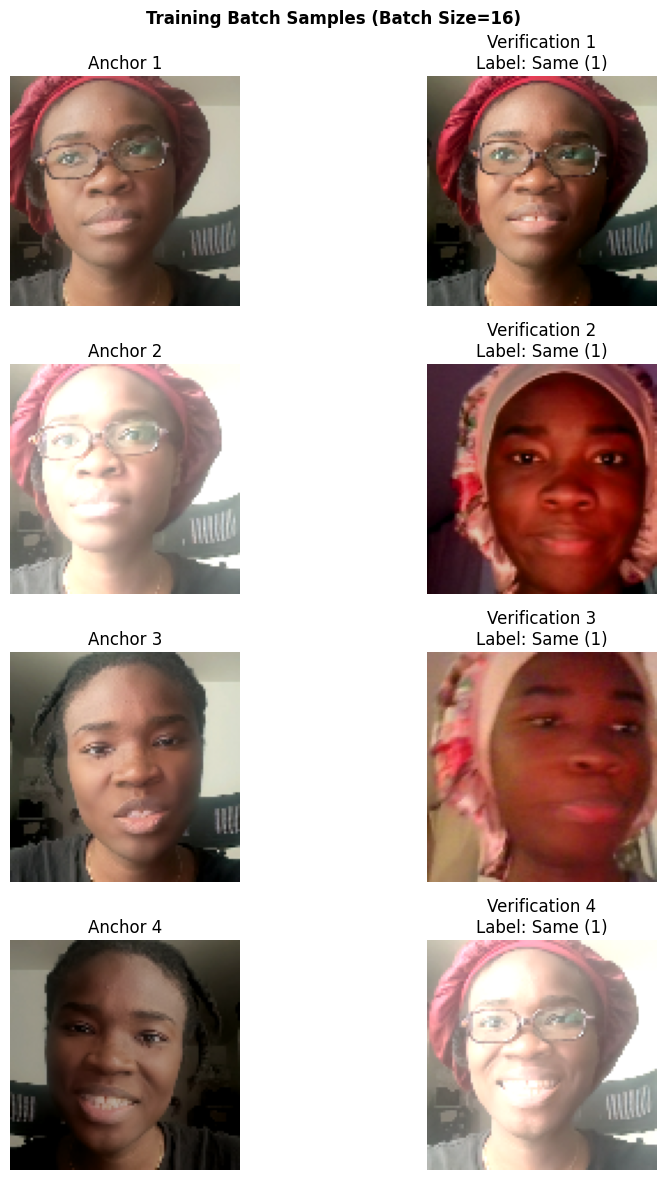


✓ Batch visualized


In [7]:
if train_data is not None:
    print("Visualizing Batch...\n")

    # Extract the first batch
    for anchor_batch, verification_batch, label_batch in train_data.take(1):
        print(f"Batch Information:")
        print(f"  Anchor Batch: {anchor_batch.shape}")
        print(f"  Verification Batch: {verification_batch.shape}")
        print(f"  Label Batch: {label_batch.shape}")
        print(f"  Labels: {label_batch.numpy()}")
        print(f"  Positive Samples: {int(np.sum(label_batch.numpy()))}")
        print(f"  Negative Samples: {int(np.sum(1 - label_batch.numpy()))}")

        # Visualize 4 pairs
        fig, axes = plt.subplots(4, 2, figsize=(10, 12))
        fig.suptitle(f'Training Batch Samples (Batch Size={config.BATCH_SIZE})', fontsize=12, fontweight='bold')

        for i in range(4):
            # Anchor
            axes[i, 0].imshow(anchor_batch[i].numpy())
            axes[i, 0].set_title(f"Anchor {i+1}")
            axes[i, 0].axis('off')

            # Verification
            label_text = f"Same (1)" if label_batch[i].numpy() == 1 else f"Different (0)"
            axes[i, 1].imshow(verification_batch[i].numpy())
            axes[i, 1].set_title(f"Verification {i+1}\nLabel: {label_text}")
            axes[i, 1].axis('off')

        plt.tight_layout()
        plt.show()

        print("\n✓ Batch visualized")
else:
    print("⚠️ Dataset not created")

## 2.7 Verify Augmentation per Epoch


Demonstrating On-The-Fly Augmentation (different image per epoch)...



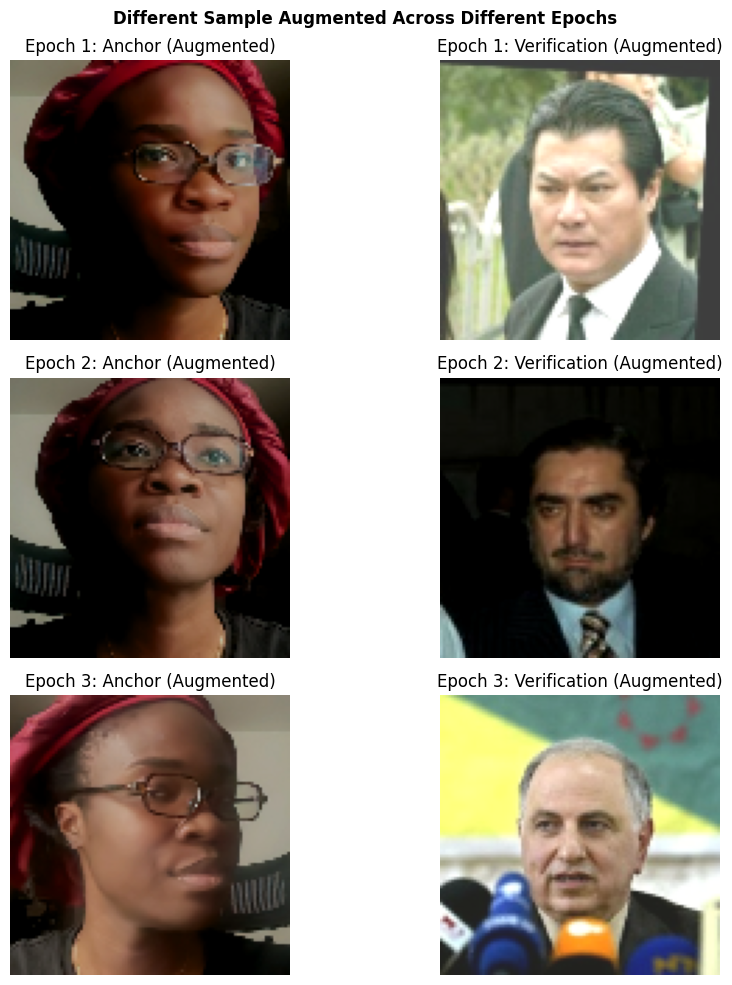

In [8]:
if train_data is not None:
    print("\nDemonstrating On-The-Fly Augmentation (different image per epoch)...\n")

    # Take the same batch 3 times
    fig, axes = plt.subplots(3, 2, figsize=(10, 10))
    fig.suptitle('Different Sample Augmented Across Different Epochs', fontsize=12, fontweight='bold')

    epoch = 0
    for anchor_batch, verification_batch, label_batch in train_data.take(3):
        # Visualize the first sample from the batch
        axes[epoch, 0].imshow(anchor_batch[0].numpy())
        axes[epoch, 0].set_title(f"Epoch {epoch+1}: Anchor (Augmented)")
        axes[epoch, 0].axis('off')

        axes[epoch, 1].imshow(verification_batch[0].numpy())
        axes[epoch, 1].set_title(f"Epoch {epoch+1}: Verification (Augmented)")
        axes[epoch, 1].axis('off')

        epoch += 1

    plt.tight_layout()
    plt.show()

## 2.8 Summary & Next Steps

In [9]:
print("\n" + "="*80)
print("PREPROCESSING SUMMARY")
print("="*80)

if train_data is not None:
    print(f"\n✓ Image Preprocessing:")
    print(f"  - Resized to {config.IMG_SIZE}x{config.IMG_SIZE}")
    print(f"  - Normalized to [0, 1]")

    print(f"\n✓ On-The-Fly Augmentation:")
    print(f"  - Brightness: ±{config.AugmentationConfig.BRIGHTNESS_MAX_DELTA*100:.0f}%")
    print(f"  - Contrast: {config.AugmentationConfig.CONTRAST_LOWER}x - {config.AugmentationConfig.CONTRAST_UPPER}x")
    print(f"  - Saturation: {config.AugmentationConfig.SATURATION_LOWER}x - {config.AugmentationConfig.SATURATION_UPPER}x")
    print(f"  - Flip: {config.AugmentationConfig.FLIP_PROB*100:.0f}% Horizontal")

    print(f"\n✓ Dataset Pipeline:")
    print(f"  - Train/Test Split: {config.TRAIN_SIZE:.0%} / {config.TEST_SIZE:.0%}")
    print(f"  - Batch Size: {config.BATCH_SIZE}")
    print(f"  - Shuffle Buffer: {config.DatasetConfig.SHUFFLE_BUFFER}")
    print(f"  - Prefetch Buffer: {config.DatasetConfig.PREFETCH_BUFFER}")

    print(f"\n✓ Ready for Training!")
    print(f"\nNext Step:")
    print(f"  → Notebook 03_model_architecture.ipynb")
else:
    print("\n⚠️ Pipeline not created")

print("\n" + "="*80)
print("✓ Notebook 02 completed!")
print("="*80)


PREPROCESSING SUMMARY

✓ Image Preprocessing:
  - Resized to 100x100
  - Normalized to [0, 1]

✓ On-The-Fly Augmentation:
  - Brightness: ±30%
  - Contrast: 0.8x - 1.2x
  - Saturation: 0.8x - 1.2x
  - Flip: 50% Horizontal

✓ Dataset Pipeline:
  - Train/Test Split: 70% / 30%
  - Batch Size: 16
  - Shuffle Buffer: 10000
  - Prefetch Buffer: 8

✓ Ready for Training!

Next Step:
  → Notebook 03_model_architecture.ipynb

✓ Notebook 02 completed!
